In [1]:
# This cell originally contained a non‑code description that caused a SyntaxError.
# It has been turned into a regular comment so the script can run.



In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.transforms import v2
import math
import torchvision.transforms.functional as TF
import torch.nn.functional as F



In [3]:
# Install torchinfo if it is not already available.
try:
    from torchinfo import summary
except ImportError:
    import subprocess, sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchinfo"])
    from torchinfo import summary



In [4]:
# Use the already‑extracted Kaggle input directory.
base_path = "/kaggle/input/denoising-dirty-documents"
train_dir = os.path.join(base_path, "train")
train_cleaned_dir = os.path.join(base_path, "train_cleaned")
test_dir = os.path.join(base_path, "test")




In [5]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.lower().endswith(".png"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
    return images




In [6]:
train_images = load_images_from_folder(train_dir)
train_cleaned_images = load_images_from_folder(train_cleaned_dir)
test_images = load_images_from_folder(test_dir)



In [7]:
print(f"train_images: {len(train_images)}")
print(f"train_cleaned_images: {len(train_cleaned_images)}")
print(f"test_images: {len(test_images)}")



train_images: 115
train_cleaned_images: 115
test_images: 29


In [8]:
# Show first training image shape (optional)
_ = train_images[0]



In [9]:
# Show first cleaned image shape (optional)
_ = train_cleaned_images[0]



In [10]:
# Show first test image shape (optional)
_ = test_images[0]



In [11]:
train_sizes = [img.shape[:2] for img in train_images]
train_cleaned_sizes = [img.shape[:2] for img in train_cleaned_images]
test_sizes = [img.shape[:2] for img in test_images]



In [12]:
unique_train_sizes = np.unique(train_sizes, axis=0)
unique_train_cleaned_sizes = np.unique(train_cleaned_sizes, axis=0)
unique_test_sizes = np.unique(test_sizes, axis=0)



In [13]:
print(f"train_images:\n {unique_train_sizes}")
print(f"train_cleaned_images:\n {unique_train_cleaned_sizes}")
print(f"test_images:\n {unique_test_sizes}")




train_images:
 [[258 540]
 [420 540]]
train_cleaned_images:
 [[258 540]
 [420 540]]
test_images:
 [[258 540]
 [420 540]]


In [14]:
class PadToSize:
    def __init__(self, target_size):
        self.target_size = target_size  # (height, width)

    def __call__(self, img):
        _, height, width = img.shape
        target_height, target_width = self.target_size

        pad_top = (target_height - height) // 2
        pad_bottom = target_height - height - pad_top
        pad_left = (target_width - width) // 2
        pad_right = target_width - width - pad_left

        return TF.pad(img, [pad_left, pad_top, pad_right, pad_bottom], fill=0)




In [15]:
class Grayscale:
    def __call__(self, img):
        pil_img = TF.to_pil_image(img) if isinstance(img, torch.Tensor) else img
        grayscale_img = pil_img.convert("L")
        return TF.to_tensor(grayscale_img)




In [16]:
train_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        v2.RandomApply([v2.GaussianBlur(kernel_size=3)], p=0.4),
        v2.RandomApply([v2.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

val_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

test_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)




In [17]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_files = sorted(
            [
                os.path.join(data_dir, f)
                for f in os.listdir(data_dir)
                if f.lower().endswith(".png")
            ]
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image




In [18]:
train_files = sorted(
    [
        os.path.join(train_dir, f)
        for f in os.listdir(train_dir)
        if f.lower().endswith(".png")
    ]
)
cleaned_files = sorted(
    [
        os.path.join(train_cleaned_dir, f)
        for f in os.listdir(train_cleaned_dir)
        if f.lower().endswith(".png")
    ]
)

train_files, val_files, cleaned_train, cleaned_val = train_test_split(
    train_files, cleaned_files, test_size=2 / 9, random_state=42
)




In [19]:
class PairedImageDataset(Dataset):
    def __init__(self, train_files, cleaned_files, transform=None):
        self.train_files = train_files
        self.cleaned_files = cleaned_files
        self.transform = transform

    def __len__(self):
        return len(self.train_files)

    def __getitem__(self, idx):
        train_img = Image.open(self.train_files[idx]).convert("RGB")
        cleaned_img = Image.open(self.cleaned_files[idx]).convert("RGB")
        if self.transform:
            train_img = self.transform(train_img)
            cleaned_img = self.transform(cleaned_img)
        return train_img, cleaned_img




In [20]:
train_dataset = PairedImageDataset(train_files, cleaned_train, train_transforms)
val_dataset = PairedImageDataset(val_files, cleaned_val, val_transforms)
test_dataset = ImageDataset(test_dir, test_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)




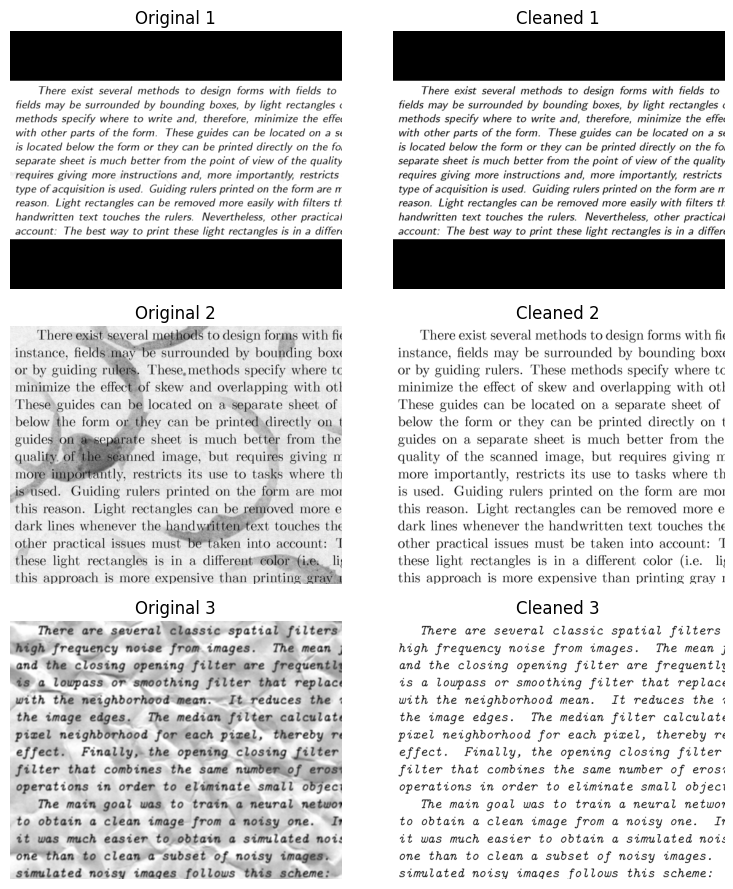

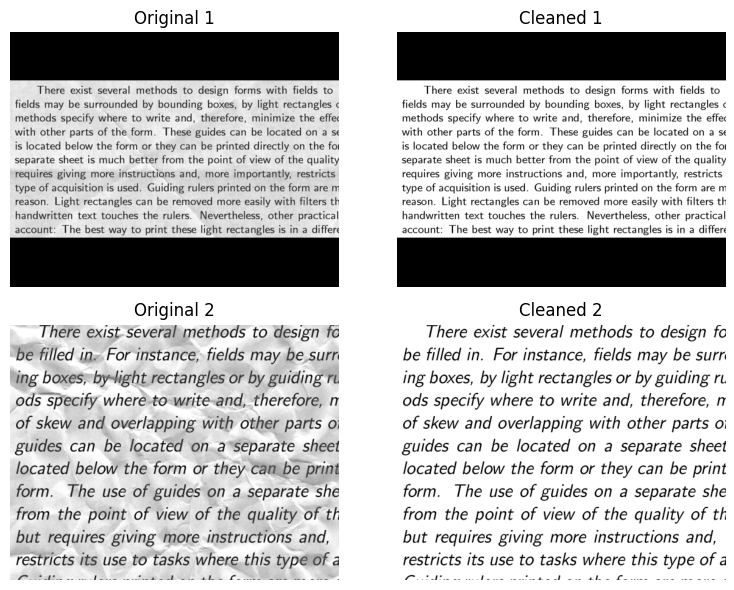

In [21]:
def visualize_paired_dataset(paired_loader, num_images=5):
    for train_images, cleaned_images in paired_loader:
        fig, axes = plt.subplots(num_images, 2, figsize=(8, num_images * 3))
        for i in range(num_images):
            axes[i, 0].imshow(
                train_images[i].permute(1, 2, 0).cpu().numpy(), cmap="gray"
            )
            axes[i, 0].set_title(f"Original {i+1}")
            axes[i, 0].axis("off")
            axes[i, 1].imshow(
                cleaned_images[i].permute(1, 2, 0).cpu().numpy(), cmap="gray"
            )
            axes[i, 1].set_title(f"Cleaned {i+1}")
            axes[i, 1].axis("off")
        plt.tight_layout()
        plt.show()
        break


visualize_paired_dataset(train_loader, num_images=3)
visualize_paired_dataset(val_loader, num_images=2)



In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)




cuda


In [23]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(1, 8, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(8, 16, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(16, 32, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(32, 64, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.dec5 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                64,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=64,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                32,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=32,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                16,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=16,
                bias=False,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(p=0.2),
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                8,
                8,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=8,
                bias=False,
            ),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(p=0.1),
        )
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(8, 1, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                1,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=1,
                bias=False,
            ),
            nn.Sigmoid(),
        )
        self.conv4 = nn.Conv2d(64, 32, kernel_size=1, stride=1, bias=False)
        self.conv5 = nn.Conv2d(128, 64, kernel_size=1, stride=1, bias=False)

    def forward(self, x):
        enc1_out = self.enc1(x)
        enc2_out = self.enc2(enc1_out)
        enc3_out = self.enc3(enc2_out)
        enc4_out = self.enc4(enc3_out)
        enc5_out = self.enc5(enc4_out)

        dec5_out = self.dec5(enc5_out)
        dec5_out = F.interpolate(
            dec5_out, size=(26, 33), mode="bilinear", align_corners=False
        )
        dec5_out = torch.cat([dec5_out, enc4_out], dim=1)
        dec5_out = self.conv5(dec5_out)

        dec4_out = self.dec4(enc4_out)
        dec4_out = F.interpolate(
            dec4_out, size=(52, 67), mode="bilinear", align_corners=False
        )
        dec4_out = torch.cat([dec4_out, enc3_out], dim=1)
        dec4_out = self.conv4(dec4_out)

        dec3_out = self.dec3(dec4_out)
        dec3_out = F.interpolate(
            dec3_out, size=(105, 135), mode="bilinear", align_corners=False
        )

        dec2_out = self.dec2(dec3_out)
        dec2_out = F.interpolate(
            dec2_out, size=(210, 270), mode="bilinear", align_corners=False
        )

        dec1_out = self.dec1(dec2_out)
        dec1_out = F.interpolate(
            dec1_out, size=(420, 540), mode="bilinear", align_corners=False
        )

        outputs = torch.clamp(dec1_out, min=0.001, max=0.999)
        return outputs


model = DenoisingAutoencoder().to(device)



In [24]:
summary(model, input_size=(16, 1, 420, 540), device=device)




Layer (type:depth-idx)                   Output Shape              Param #
DenoisingAutoencoder                     [16, 1, 420, 540]         --
├─Sequential: 1-1                        [16, 8, 210, 270]         --
│    └─Conv2d: 2-1                       [16, 1, 420, 540]         9
│    └─Conv2d: 2-2                       [16, 8, 420, 540]         8
│    └─BatchNorm2d: 2-3                  [16, 8, 420, 540]         16
│    └─ReLU: 2-4                         [16, 8, 420, 540]         --
│    └─MaxPool2d: 2-5                    [16, 8, 210, 270]         --
├─Sequential: 1-2                        [16, 16, 105, 135]        --
│    └─Conv2d: 2-6                       [16, 8, 210, 270]         576
│    └─Conv2d: 2-7                       [16, 16, 210, 270]        128
│    └─BatchNorm2d: 2-8                  [16, 16, 210, 270]        32
│    └─ReLU: 2-9                         [16, 16, 210, 270]        --
│    └─Dropout: 2-10                     [16, 16, 210, 270]        --
│    └─MaxPool2

In [25]:
class RMSELoss(nn.Module):
    def forward(self, pred, target):
        return torch.sqrt(F.mse_loss(pred, target))




In [26]:
class HybridLoss(nn.Module):
    def __init__(self, lambda_rmse=0.8, lambda_l1=0.2):
        super(HybridLoss, self).__init__()
        self.lambda_rmse = lambda_rmse
        self.lambda_l1 = lambda_l1
        self.rmse_loss = RMSELoss()
        self.l1_loss = nn.L1Loss()

    def forward(self, pred, target):
        return self.lambda_rmse * self.rmse_loss(
            pred, target
        ) + self.lambda_l1 * self.l1_loss(pred, target)




In [27]:
criterion = HybridLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)



In [28]:
epochs = 200  # reduced from 1000 to keep runtime reasonable
patience = 5
early_stop_counter = 0
best_val_loss = float("inf")
best_model_state = None

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_rmse = 0.0
    for train_imgs, train_cleaned in train_loader:
        train_imgs, train_cleaned = train_imgs.to(device), train_cleaned.to(device)
        optimizer.zero_grad()
        outputs = model(train_imgs)
        loss = criterion(outputs, train_cleaned)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_rmse += RMSELoss()(outputs, train_cleaned).item()
    train_loss /= len(train_loader)
    train_rmse /= len(train_loader)
    print(
        f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.4f}, RMSE: {train_rmse:.4f}"
    )

    model.eval()
    val_loss = 0.0
    val_rmse = 0.0
    with torch.no_grad():
        for val_imgs, val_cleaned in val_loader:
            val_imgs, val_cleaned = val_imgs.to(device), val_cleaned.to(device)
            outputs = model(val_imgs)
            loss = criterion(outputs, val_cleaned)
            val_loss += loss.item()
            val_rmse += RMSELoss()(outputs, val_cleaned).item()
    val_loss /= len(val_loader)
    val_rmse /= len(val_loader)
    print(f"Validation loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        early_stop_counter = 0
        print("New best model saved.")
    else:
        early_stop_counter += 1
        print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Early stopping triggered.")
        break

if best_model_state is not None:
    torch.save(best_model_state, "best_model.pth")
    print(f"Best model saved with val_loss = {best_val_loss:.4f}")



Epoch 1/200 - Train loss: 0.4600, RMSE: 0.4654
Validation loss: 0.4723, RMSE: 0.4746
New best model saved.
Epoch 2/200 - Train loss: 0.4245, RMSE: 0.4298
Validation loss: 0.4651, RMSE: 0.4675
New best model saved.
Epoch 3/200 - Train loss: 0.4002, RMSE: 0.4060
Validation loss: 0.4463, RMSE: 0.4493
New best model saved.
Epoch 4/200 - Train loss: 0.3365, RMSE: 0.3441
Validation loss: 0.4180, RMSE: 0.4235
New best model saved.
Epoch 5/200 - Train loss: 0.2998, RMSE: 0.3084
Validation loss: 0.3898, RMSE: 0.4016
New best model saved.
Epoch 6/200 - Train loss: 0.2482, RMSE: 0.2600
Validation loss: 0.3770, RMSE: 0.4007
New best model saved.
Epoch 7/200 - Train loss: 0.2323, RMSE: 0.2472
Validation loss: 0.3831, RMSE: 0.4166
No improvement. Early stop counter: 1/5
Epoch 8/200 - Train loss: 0.2069, RMSE: 0.2229
Validation loss: 0.3749, RMSE: 0.4109
New best model saved.
Epoch 9/200 - Train loss: 0.2129, RMSE: 0.2306
Validation loss: 0.3234, RMSE: 0.3550
New best model saved.
Epoch 10/200 - Trai

In [29]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        break  # just to get a batch for visualisation




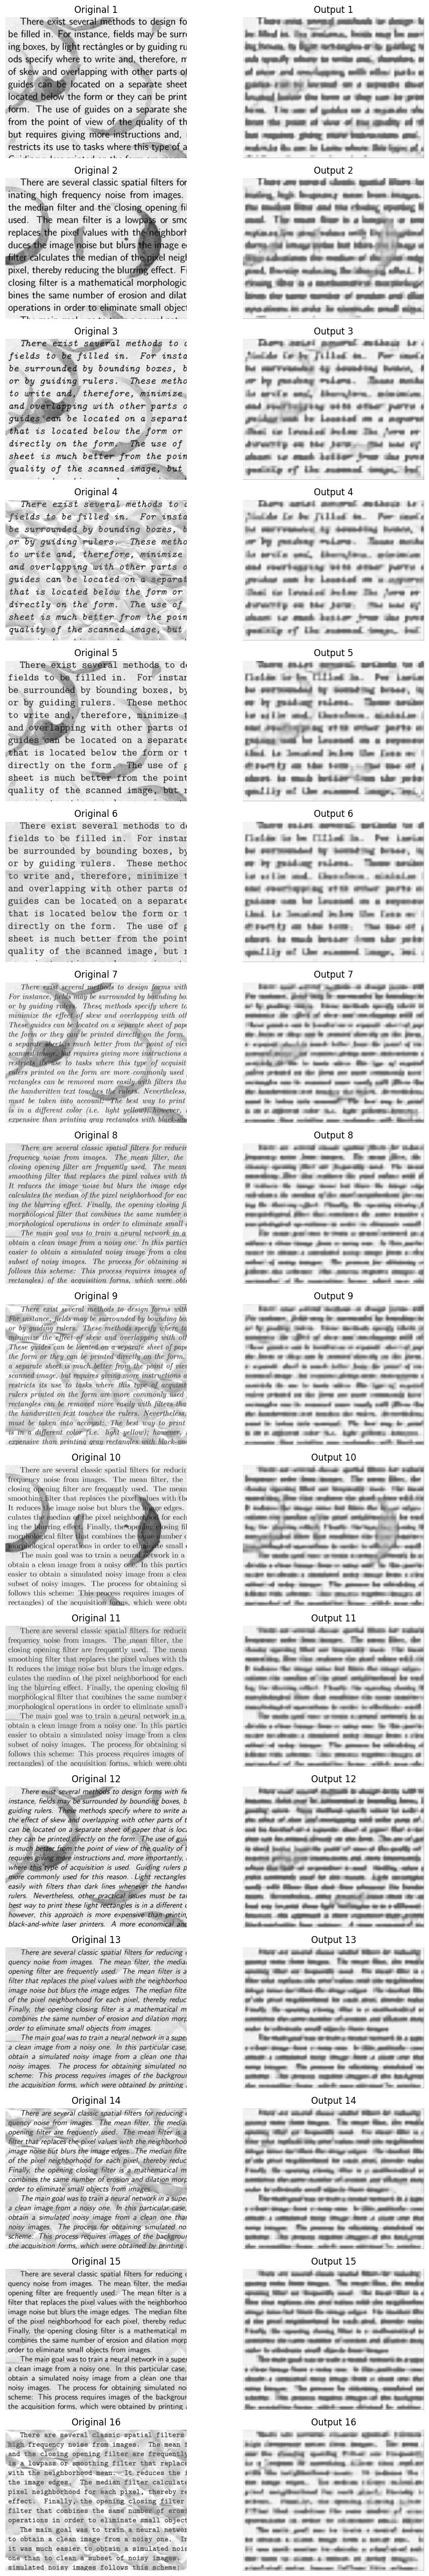

In [30]:
def visualize_images_and_outputs(images, outputs):
    num_images = images.size(0)
    fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 3))
    for i in range(num_images):
        axes[i, 0].imshow(images[i].cpu().numpy().squeeze(), cmap="gray")
        axes[i, 0].set_title(f"Original {i+1}")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(outputs[i].cpu().detach().numpy().squeeze(), cmap="gray")
        axes[i, 1].set_title(f"Output {i+1}")
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.show()


visualize_images_and_outputs(images, outputs)



In [31]:
print(f"Test directory: {test_dir}")



Test directory: /kaggle/input/denoising-dirty-documents/test


In [32]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_outputs = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        all_outputs.append(out.cpu())
all_outputs = torch.cat(all_outputs, dim=0)
print("All outputs shape:", all_outputs.shape)



All outputs shape: torch.Size([29, 1, 420, 540])


In [33]:
import csv

target_size = (420, 540)  # (height, width)


def compute_padding(orig_size, target_size):
    orig_h, orig_w = orig_size
    tgt_h, tgt_w = target_size
    pad_top = (tgt_h - orig_h) // 2 if tgt_h > orig_h else 0
    pad_left = (tgt_w - orig_w) // 2 if tgt_w > orig_w else 0
    return pad_top, pad_left


def remove_padding(pred, orig_size, target_size):
    orig_h, orig_w = orig_size
    pad_top, pad_left = compute_padding(orig_size, target_size)
    return pred[:, pad_top : pad_top + orig_h, pad_left : pad_left + orig_w]


test_file_paths = sorted(
    [
        os.path.join(test_dir, f)
        for f in os.listdir(test_dir)
        if f.lower().endswith(".png")
    ],
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
)

submission_path = "/kaggle/working/submission.csv"
with open(submission_path, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "value"])
    for idx, file_path in enumerate(test_file_paths):
        image_id = os.path.splitext(os.path.basename(file_path))[0]
        orig_img = Image.open(file_path).convert("L")
        orig_w, orig_h = orig_img.size
        orig_size = (orig_h, orig_w)

        pred = all_outputs[idx]  # (1, 420, 540)
        cropped = remove_padding(pred, orig_size, target_size)  # (1, h, w)
        pred_np = cropped.squeeze(0).cpu().numpy()
        for row in range(orig_h):
            for col in range(orig_w):
                pid = f"{image_id}_{row+1}_{col+1}"
                writer.writerow([pid, float(pred_np[row, col])])

print(f"Submission file created at {submission_path}")

Submission file created at /kaggle/working/submission.csv
